In [2]:
import pandas as pd
import numpy as np
import os
from pathlib import Path

In [3]:
from pathlib import Path

try:
    THIS_DIR = Path(__file__).resolve().parent
except NameError:
    # Running in Jupyter/Notebook
    THIS_DIR = Path.cwd()

PLOTS_DIR = Path(THIS_DIR, "PLOTS")
PLOT_TYPES = [
    "accuracy_distribution.png",
    "accuracy_vs_class_size.png",
    "accuracy_vs_f1_comparison.png",
    "boxplot_comparison.png",
    "f1_distribution.png"
]

# Model configurations
MODEL_CONFIGS = {
    "SWIN_BASE": {
        "name": "SWIN Base",
        "15k": "SWIN_BASE_UNFROZEN_15K",
        "21k": "SWIN_BASE_UNFROZEN_21K_checkpoint-210888",
        "50k": "SWIN_BASE_UNFROZEN_50K_checkpoint-184527"
    },
    "SWIN_LARGE": {
        "name": "SWIN Large",
        "15k": "SWIN_LARGE_UNFROZEN_15K_checkpoint-262450",
        "21k": "SWIN_LARGE_UNFROZEN_21K_checkpoint-210876",
        "50k": "SWIN_LARGE_UNFROZEN_50K_checkpoint-298741"
    },
    "SWINV2_BASE": {
        "name": "SWIN V2 Base",
        "15k": "SWINV2_BASE_UNFROZEN_15K_checkpoint-682370",
        "21k": "SWINV2_BASE_UNFROZEN_21K_checkpoint-667755",
        "50k": "SWINV2_BASE_UNFROZEN_50K_checkpoint-492030"
    },
    "SWINV2_LARGE": {
        "name": "SWIN V2 Large",
        "15k": "SWINV2_LARGE_UNFROZEN_15K_checkpoint-377928",
        "21k": "SWINV2_LARGE_UNFROZEN_21K_checkpoint-351450",
        "50k": "SWINV2_LARGE_UNFROZEN_50K_checkpoint-281160"
    }
}

In [6]:
label_sizes = ["15k", "21k", "50k"]

for label_size in label_sizes:
    print(f"\n{'=' * 60}")
    print(f"Label set size: {label_size} (averaged across models)")
    print(f"{'=' * 60}")

    bad_counts = []
    struggling_counts = []
    good_counts = []

    for _, model_config in MODEL_CONFIGS.items():
        checkpoint_path = os.path.join(PLOTS_DIR, model_config[label_size])
        metrics_csv_path = os.path.join(checkpoint_path, "per_class_metrics.csv")
        metrics_df = pd.read_csv(metrics_csv_path)

        bad_count = len(metrics_df[metrics_df["f1"] == 0])
        struggling_count = len(metrics_df[(metrics_df["f1"] > 0.0) & (metrics_df["f1"] <= 0.5)])
        good_count = len(metrics_df[metrics_df["f1"] > 0.5])

        bad_counts.append(bad_count)
        struggling_counts.append(struggling_count)
        good_counts.append(good_count)

        print(f"  {model_config['name']:<14} -> F1=0: {bad_count:6d}, 0<F1<=0.5: {struggling_count:6d}, F1>0.5: {good_count:6d}")

    avg_bad_count = np.mean(bad_counts)
    avg_struggling_count = np.mean(struggling_counts)
    avg_good_count = np.mean(good_counts)

    print("\nAverages across models:")
    print(f"  F1=0        -> avg classes: {avg_bad_count:.2f}")
    print(f"  0<F1<=0.5   -> avg classes: {avg_struggling_count:.2f}")
    print(f"  F1>0.5      -> avg classes: {avg_good_count:.2f}")
    print()


Label set size: 15k (averaged across models)
  SWIN Base      -> F1=0:    520, 0<F1<=0.5:   1366, F1>0.5:  13510
  SWIN Large     -> F1=0:    505, 0<F1<=0.5:   1332, F1>0.5:  13555
  SWIN V2 Base   -> F1=0:    518, 0<F1<=0.5:   1510, F1>0.5:  13351
  SWIN V2 Large  -> F1=0:    587, 0<F1<=0.5:   1715, F1>0.5:  13092

Averages across models:
  F1=0        -> avg classes: 532.50
  0<F1<=0.5   -> avg classes: 1480.75
  F1>0.5      -> avg classes: 13377.00


Label set size: 21k (averaged across models)
  SWIN Base      -> F1=0:   6803, 0<F1<=0.5:   1088, F1>0.5:  16004
  SWIN Large     -> F1=0:   7520, 0<F1<=0.5:   1271, F1>0.5:  15289
  SWIN V2 Base   -> F1=0:   7178, 0<F1<=0.5:    995, F1>0.5:  15576
  SWIN V2 Large  -> F1=0:   7670, 0<F1<=0.5:   1248, F1>0.5:  14925

Averages across models:
  F1=0        -> avg classes: 7292.75
  0<F1<=0.5   -> avg classes: 1150.50
  F1>0.5      -> avg classes: 15448.50


Label set size: 50k (averaged across models)
  SWIN Base      -> F1=0:  13535, 0<F

15k: showing up to 99th percentile (<= 22); 138 classes above this range.


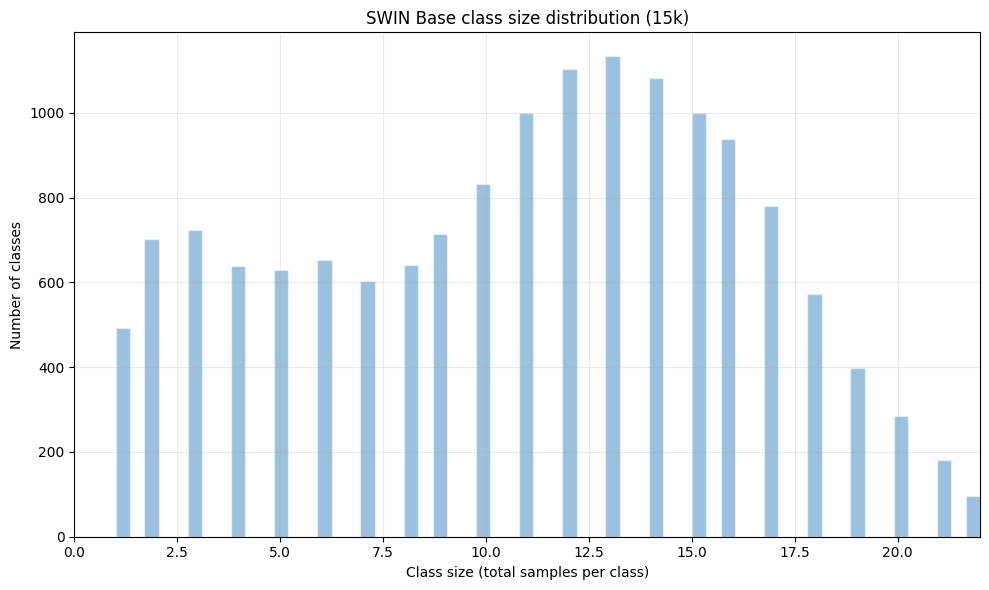

21k: showing up to 99th percentile (<= 12); 210 classes above this range.


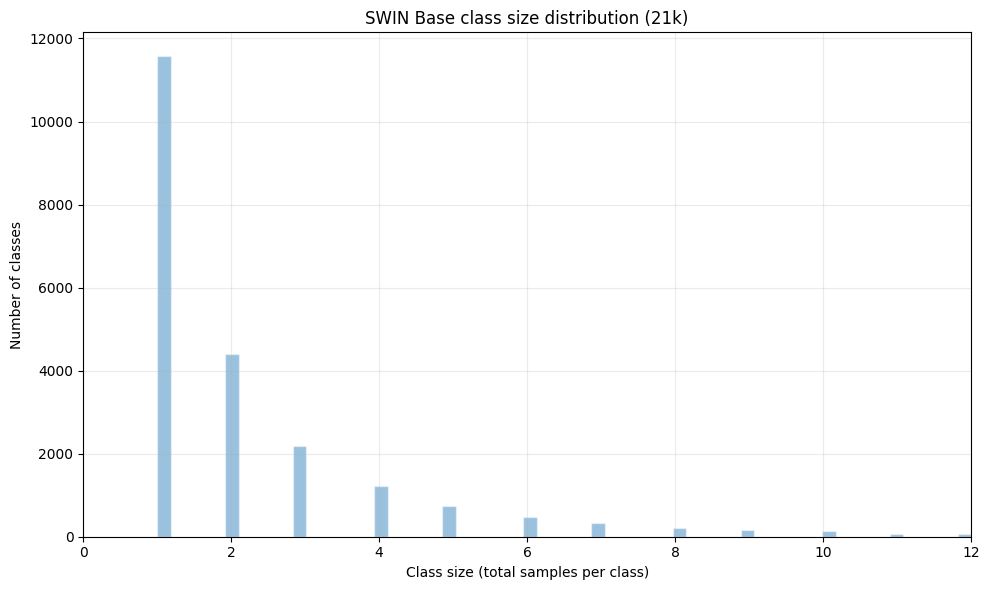

50k: showing up to 99th percentile (<= 65); 508 classes above this range.


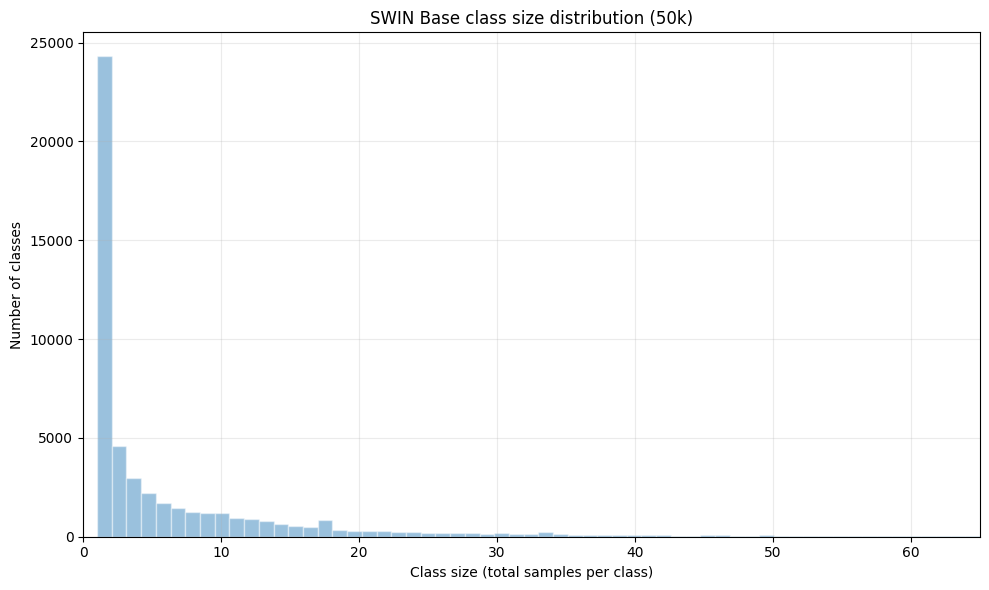

In [9]:
import matplotlib.pyplot as plt

label_sizes = ["15k", "21k", "50k"]
swin_base_config = MODEL_CONFIGS["SWIN_BASE"]

for label_size in label_sizes:
    csv_path = PLOTS_DIR / swin_base_config[label_size] / "per_class_metrics.csv"
    if not csv_path.exists():
        raise FileNotFoundError(f"Missing CSV file: {csv_path}")

    metrics_df = pd.read_csv(csv_path)
    if "total" not in metrics_df.columns:
        raise ValueError(f"'total' column not found in {csv_path}")

    totals = metrics_df["total"].dropna()
    totals = totals[totals > 0]
    if totals.empty:
        print(f"No positive class sizes for {label_size}, skipping")
        continue

    # Keep axis readable by focusing on where most classes lie.
    x_max = totals.quantile(0.99)
    display_totals = totals[totals <= x_max]

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.hist(
        display_totals,
        bins=60,
        density=False,
        alpha=0.45,
        color="tab:blue",
        edgecolor="white",
    )

    ax.set_xlabel("Class size (total samples per class)")
    ax.set_ylabel("Number of classes")
    ax.set_title(f"SWIN Base class size distribution ({label_size})")
    ax.set_xlim(0, x_max)
    ax.grid(True, alpha=0.25)

    print(
        f"{label_size}: showing up to 99th percentile (<= {x_max:.0f}); "
        f"{len(totals) - len(display_totals)} classes above this range."
    )

    plt.tight_layout()
    plt.show()